<a href="https://colab.research.google.com/github/FadilSadBoy20/Fadil-Insanus-Siddik_2411532013_ML2526/blob/main/Praktikum1/Dataset_California_Housing_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Menampilkan beberapa data awal
print("5 Data Pertama:")
print(df.head())

# Memisahkan variabel independen dan dependen
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]


5 Data Pertama:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# Scaling data ke rentang [0,1]
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nShape Data Latih:", X_train_scaled.shape)
print("Shape Data Uji:", X_test_scaled.shape)


Shape Data Latih: (14448, 8)
Shape Data Uji: (6192, 8)


In [4]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("\n=== Model Linear Regression ===")
print("Intercept:", model.intercept_)
print("Slope / Coefficients:", model.coef_)


=== Model Linear Regression ===
Intercept: 3.721516132506502
Slope / Coefficients: [  6.39513914   0.49408893 -14.78075919  20.98391128  -0.2003207
  -4.08551937  -3.98214561  -4.37460957]



=== Evaluasi Model ===
MSE : 0.5296293151408232
R^2 : 0.597142973735963


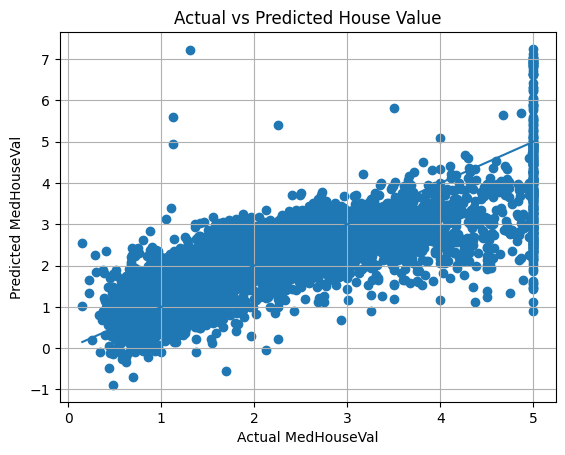

In [5]:
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Evaluasi Model ===")
print("MSE :", mse)
print("R^2 :", r2)

# Plot hubungan nilai aktual vs prediksi
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("Actual vs Predicted House Value")

# garis referensi
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.grid(True)
plt.show()

In [7]:
with open("model_california_housing.pkl", "wb") as file:
    pickle.dump(model, file)

with open("scaler_california_housing.pkl", "wb") as file:
    pickle.dump(scaler, file)